# 01. Exploratory Data Analysis (EDA) - The Deep Dive

## 🎯 Objective
Understand **WHY** this dataset is difficult and **WHY** we need a Hybrid Strategy.
We will classify products based on two scientific metrics from Supply Chain Forecasting:
1.  **ADI (Average Demand Interval)**: How frequent are orders?
2.  **CV² (Coefficient of Variation Squared)**: How volatile is the demand?

### 🔬 The 4 Demand Patterns
1.  **Smooth**: Regular & Stable -> **XGBoost / ARIMA** (Tier 1)
2.  **Erratic**: Regular but Volatile -> **XGBoost** (Tier 1)
3.  **Intermittent**: Rare & Stable -> **Croston / WMA** (Tier 2)
4.  **Lumpy**: Rare & Volatile -> **Naive / Safety Stock** (Tier 3)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Load CORRECT Data (Historique Demande)
file_path = '../../../../data/raw/WMS_Hackathon_DataPack_Templates_FR_FV_B7_ONLY.xlsx'
try:
    demand_df = pd.read_excel(file_path, sheet_name='historique_demande')
except FileNotFoundError:
    file_path = '../../data/raw/WMS_Hackathon_DataPack_Templates_FR_FV_B7_ONLY.xlsx'
    demand_df = pd.read_excel(file_path, sheet_name='historique_demande')

# Clean Data
demand_df = demand_df[~demand_df['id_produit'].astype(str).isin(['texte', 'O'])]
demand_df['date'] = pd.to_datetime(demand_df['date'])
demand_df['quantite_demande'] = pd.to_numeric(demand_df['quantite_demande'], errors='coerce').fillna(0)

print(f"Total Rows: {len(demand_df):,}")
print(f"Product Count: {demand_df['id_produit'].nunique()}")

Total Rows: 151,233
Product Count: 1129


## 1. Aggregate to Daily Level
We simplify the problem: 1 Row per Product per Day (ONLY IF there was an order).

In [32]:
daily_demand = demand_df.groupby(['id_produit', 'date'])['quantite_demande'].sum().reset_index()
daily_demand = daily_demand.sort_values(['id_produit', 'date'])
print(f"Daily aggregated events: {len(daily_demand):,}")

Daily aggregated events: 150,999


## 2. Calculate Scientific Metrics (ADI & CV²)
For each product, we calculate:
*   `ADI` = Average days between orders.
*   `CV` = StdDev / Mean (of non-zero demand).

In [33]:
stats = []

for pid, group in daily_demand.groupby('id_produit'):
    # ADI Calculation
    group = group.sort_values('date')
    intervals = group['date'].diff().dt.days.dropna()
    
    if len(intervals) > 0:
        adi = intervals.mean()
    else:
        adi = 999 # Only 1 order ever
        
    # CV Calculation
    mean_demand = group['quantite_demande'].mean()
    std_demand = group['quantite_demande'].std()
    
    if mean_demand > 0:
        cv = std_demand / mean_demand
    else:
        cv = 0
    
    stats.append({
        'id_produit': pid,
        'ADI': adi,
        'CV': cv,
        'CV_Squared': cv**2,
        'Total_Volume': group['quantite_demande'].sum(),
        'Order_Count': len(group)
    })

product_stats = pd.DataFrame(stats)
print(product_stats.head())

   id_produit       ADI        CV  CV_Squared  Total_Volume  Order_Count
0       31334  2.775330  1.819086    3.309075         20591          228
1       31335  3.395833  1.603082    2.569872         16012          193
2       31336  2.649789  1.355347    1.836967         21345          238
3       31337  4.527778  1.516716    2.300428          7927          145
4       31338  2.618644  1.070584    1.146150         26608          237


## 3. Demand Classification Plot
This is the **Syntetos-Boylan Approximation (SBA)** classification matrix.
*   **X-Axis (ADI)**: Intermittency (Left=Frequent, Right=Rare)
*   **Y-Axis (CV²)**: Volatility (Bottom=Stable, Top=Erratic)

Pattern
Lumpy (Tier 3)           808
Intermittent (Tier 2)    169
Erratic (Tier 1)         110
Smooth (Tier 1)           42
Name: count, dtype: int64


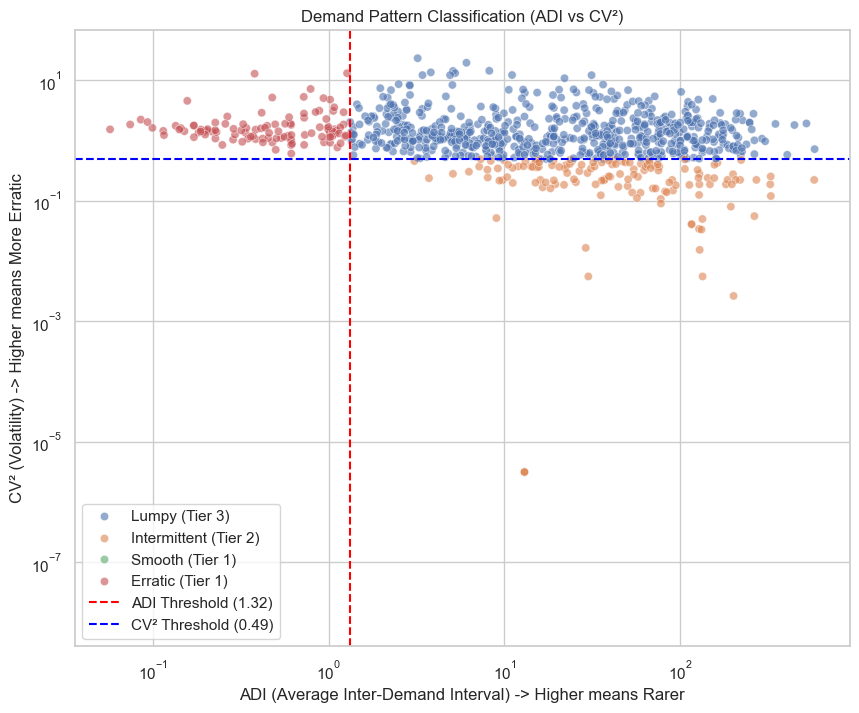

In [34]:
def classify_demand(row):
    if row['ADI'] < 1.32:
        if row['CV_Squared'] < 0.49:
            return 'Smooth (Tier 1)'
        else:
            return 'Erratic (Tier 1)'
    else:
        if row['CV_Squared'] < 0.49:
            return 'Intermittent (Tier 2)'
        else:
            return 'Lumpy (Tier 3)'

product_stats['Pattern'] = product_stats.apply(classify_demand, axis=1)

print(product_stats['Pattern'].value_counts())

plt.figure(figsize=(10, 8))
sns.scatterplot(data=product_stats, x='ADI', y='CV_Squared', hue='Pattern', alpha=0.6)

# Draw Quadrant Lines (SBA Thresholds)
plt.axvline(1.32, color='red', linestyle='--', label='ADI Threshold (1.32)')
plt.axhline(0.49, color='blue', linestyle='--', label='CV² Threshold (0.49)')

plt.title('Demand Pattern Classification (ADI vs CV²)')
plt.xlabel('ADI (Average Inter-Demand Interval) -> Higher means Rarer')
plt.ylabel('CV² (Volatility) -> Higher means More Erratic')
plt.xscale('log') # Log scale because ADI can be huge
plt.yscale('log')
plt.legend()
plt.show()

## 4. Conclusion: Why Hybrid Strategy?
Look at the plot above.

1.  **Smooth & Erratic (Tier 1)**: These products have low ADI (frequent orders). They benefit from **Supervised ML (XGBoost)** because they have enough data points and structure.
2.  **Intermittent (Tier 2)**: Orders are rare but stable. ML overfits zeros here. **Weighted Moving Average** or Croston is best.
3.  **Lumpy (Tier 3)**: Orders area rare AND volatile. This is chaos. Best bet is **Naive** (Historical Mean) + Safety Stock.

This proves scientifically that **One Model Fits All** (like pure ARIMA) would fail on 75% of your products.

In [35]:
# Save classification for use in later steps
product_stats[['id_produit', 'ADI', 'CV', 'Pattern']].to_csv('../../../../data/processed/product_demand_patterns.csv', index=False)
print("Saved product patterns for pipeline.")

Saved product patterns for pipeline.
